<a href="https://colab.research.google.com/github/TerteryanTatev/Optimization-Methods/blob/main/Interval_halving.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sympy as sp
import math
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
x = sp.symbols('x')
y = (1/4) * x **4 + x **2 - 8*x + 12
x_ext = sp.solveset(sp.diff(y), x, domain=sp.S.Reals)
f = sp.lambdify(x, y, "numpy")
x_ext

{1.67024469696273}

In [ ]:
#lab 2
ep = 0.5
d = 0.1
a, b = (0,2)
x_history = []


In [ ]:

while abs(b - a) > ep:
  print(f"a = {a}")
  print(f"b = {b}")

  x1 = (a+b - d)/2
  x2 = (a+b + d)/2

  print(f"x1 = {x1}")
  print(f"x2 = {x2}")

  y1 = y.subs(x, x1)
  y2 = y.subs(x, x2)

  print(f"y1 = {y1}")
  print(f"y2 = {y2}")
  xmin_iter = (a + b) / 2
  x_history.append(xmin_iter)

  if y1 < y2:
      b=x2
  else:
      a=x1



a = 0
b = 2
x1 = 0.95
x2 = 1.05
y1 = 5.50612656250000
y2 = 5.00637656250000
a = 0.95
b = 2
x1 = 1.425
x2 = 1.5250000000000001
y1 = 3.66148447265625
y2 = 3.47775791015625
a = 1.425
b = 2
x1 = 1.6624999999999999
x2 = 1.7625
y1 = 3.37370068969727
y2 = 3.41884619750976


In [ ]:

xmin =(a + b)/2
ymin = y.subs(x, xmin)

In [ ]:

a, b, xmin, ymin

(1.425, 1.7625, 1.59375, 3.40298867225647)

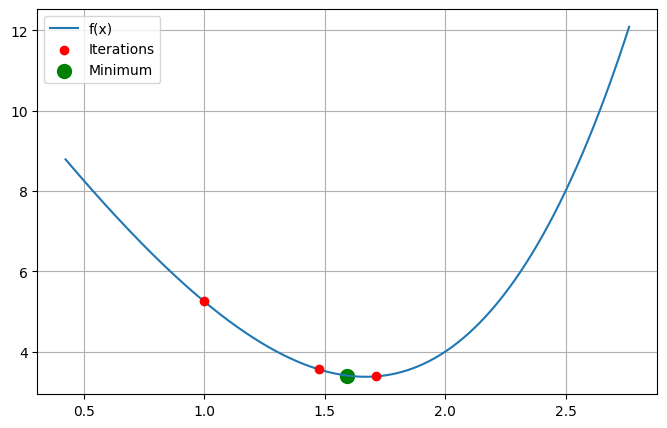

In [ ]:

X = np.linspace(a - 1, b + 1, 400)
Y = f(X)

plt.figure(figsize=(8, 5))
plt.plot(X, Y, label="f(x)")
plt.scatter(x_history, f(np.array(x_history)), color="red", zorder=5, label="Iterations")
plt.scatter(xmin, ymin, color="green", s=100, label="Minimum")

plt.legend()
plt.grid()
plt.show()

In [4]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

In [5]:
def define_function():
    x = sp.symbols('x')
    f_sym = (1/4) * x**4 + x**2 - 8*x + 12
    f_num = sp.lambdify(x, f_sym, "numpy")
    return x, f_sym, f_num


In [6]:
def analytical_extrema(x, f_sym):
    derivative = sp.diff(f_sym, x)
    extrema = sp.solveset(derivative, x, domain=sp.S.Reals)
    return extrema


In [7]:
def dichotomy_method(f_sym, a, b, ep=0.01, delta=0.001):

    x_history = []

    while abs(b - a) > ep:
        x1 = (a + b - delta) / 2
        x2 = (a + b + delta) / 2

        y1 = f_sym.subs(sp.symbols('x'), x1)
        y2 = f_sym.subs(sp.symbols('x'), x2)

        # Record midpoint
        xmin_iter = (a + b) / 2
        x_history.append(xmin_iter)

        # Interval update
        if y1 < y2:
            b = x2
        else:
            a = x1

    xmin = (a + b) / 2
    ymin = f_sym.subs(sp.symbols('x'), xmin)
    return float(xmin), float(ymin), x_history


In [9]:
def plot_results(f_num, x_history, xmin, ymin, a, b):
    X = np.linspace(a - 1, b + 1, 400)
    Y = f_num(X)

    plt.figure(figsize=(8, 5))
    plt.plot(X, Y, label="f(x)", linewidth=2)
    plt.scatter(x_history, f_num(np.array(x_history)),
                color="red", s=50, zorder=5, label="Iterations")
    plt.scatter(xmin, ymin, color="green", s=100, label="Minimum")

    # Enhance visualization
    plt.title("Dichotomy Method")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [8]:
def main():
    """
    Main program execution.
    """
    # Define function
    x, f_sym, f_num = define_function()

    # Analytical extrema for reference
    extrema = analytical_extrema(x, f_sym)
    print("Analytical extrema:", extrema)

    # Interval and precision
    a, b = 0, 2
    ep = 0.5
    delta = 0.1

    # Apply dichotomy method
    xmin, ymin, x_history = dichotomy_method(f_sym, a, b, ep, delta)
    print(f"Approximate minimum: x = {xmin}, f(x) = ymin")
    print("Iteration midpoints:", x_history)

    # Plot results
    plot_results(f_num, x_history, xmin, ymin, a, b)


Analytical extrema: {1.67024469696273}
Approximate minimum: x = 1.59375, f(x) = ymin
Iteration midpoints: [1.0, 1.475, 1.7125]


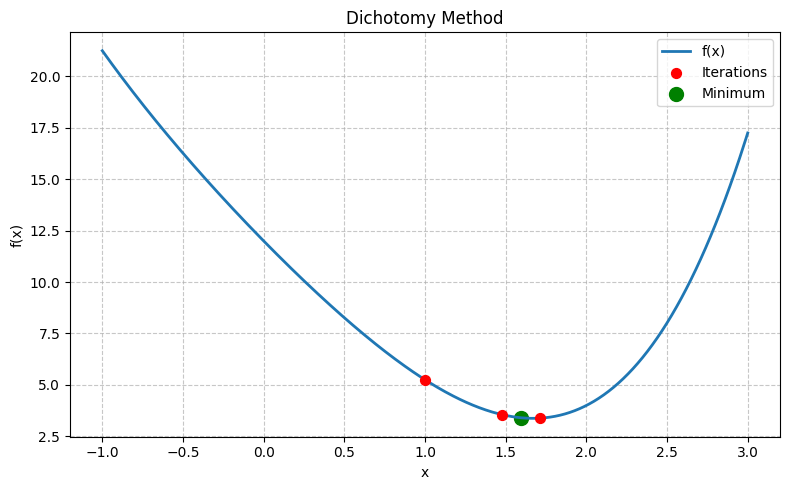

In [10]:
if __name__ == "__main__":
    main()